c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0902 - val_loss: 0.0151
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0132 - val_loss: 0.0121
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0094 - val_loss: 0.0061
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0076 - val_loss: 0.0054
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0060 - val_loss: 0.0045
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0065 - val_loss: 0.0085
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0070 - val_loss: 0.0046
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 

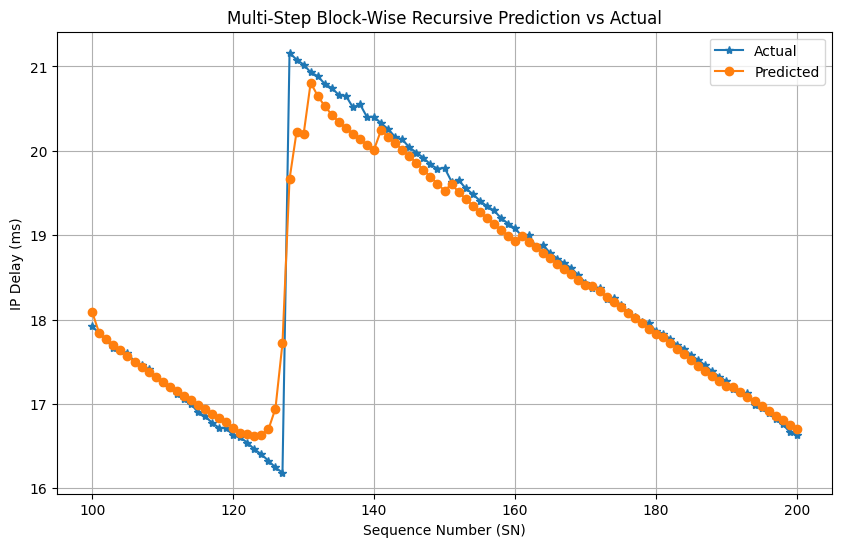

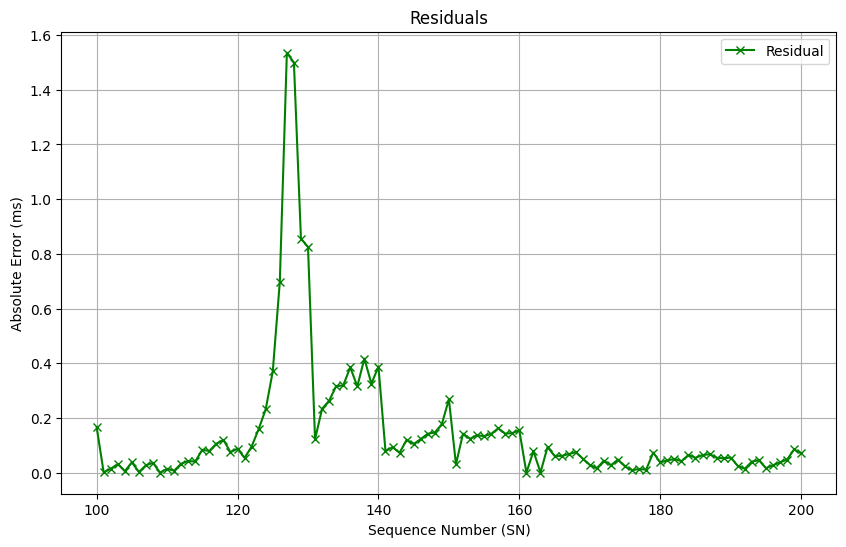

Residual Summary:
 count    3470.000000
mean        0.200877
std         0.393057
min         0.000069
25%         0.036142
50%         0.093945
75%         0.210823
max         4.112961
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Step 1: Load and Normalize Data
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# -------------------------
# Step 2: Sequence Creation
# -------------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Prepare test values
test_values = test_data['Normalized IP Delay'].values

# -------------------------
# Step 3: Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Step 4: Block-wise Multi-Step Recursive Prediction
# -------------------------
block_size = 10  # Predict 10 steps at a time
total_steps = len(test_values) - sequence_length

predictions = []
actuals = []

i = 0
while i + sequence_length + block_size <= len(test_values):
    input_sequence = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_predictions = []
    current_sequence = input_sequence.copy()

    # Step 1: Predict next 10 values recursively
    for _ in range(block_size):
        pred = model.predict(current_sequence.reshape(1, sequence_length, 1), verbose=0)
        block_predictions.append(pred[0][0])
        current_sequence = np.append(current_sequence[1:], [[pred[0][0]]], axis=0)

    predictions.extend(block_predictions)
    
    # Step 2: Store corresponding ground truth for comparison
    actual_block = test_values[i + sequence_length: i + sequence_length + block_size]
    actuals.extend(actual_block)

    # Step 3: Move to the next block (use actuals now as input)
    i += block_size

# -------------------------
# Step 5: Denormalize and Save Results
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

# Build DataFrame
result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# Optional filtering for a plot
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

# -------------------------
# Step 6: Plot and Save
# -------------------------
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Multi-Step Block-Wise Recursive Prediction vs Actual')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', marker='x', color='green')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals')
plt.legend()
plt.grid()
plt.show()

# Save results
result_df.to_csv('blockwise_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0907 - val_loss: 0.0139
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0132 - val_loss: 0.0082
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0082 - val_loss: 0.0053
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0060 - val_loss: 0.0075
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0068 - val_loss: 0.0153
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0046 - val_loss: 0.0037
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0055 - val_loss: 0.0081
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - los

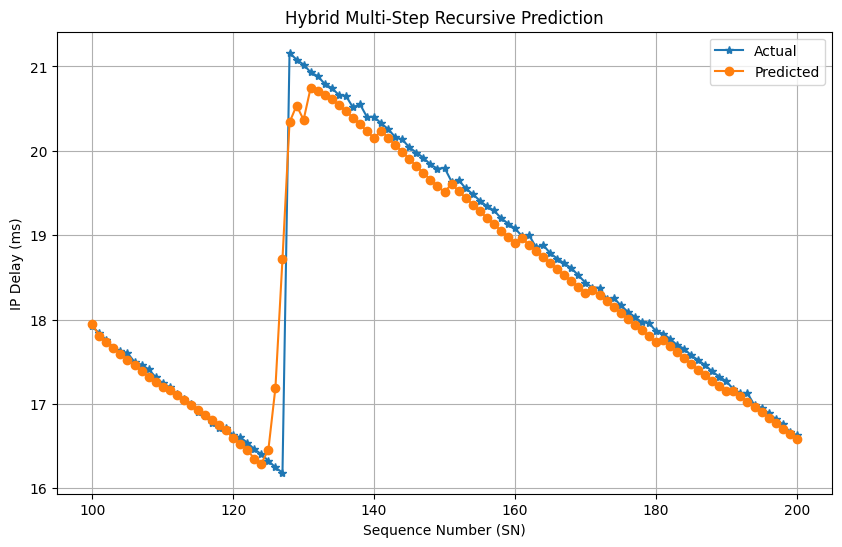

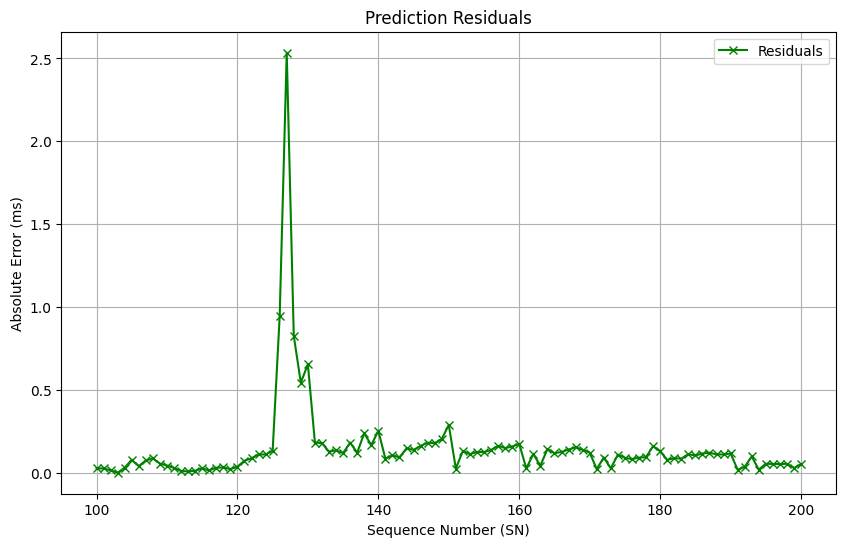

Residual Summary:
 count    3470.000000
mean        0.177898
std         0.315722
min         0.000183
25%         0.064419
50%         0.108479
75%         0.170793
max         3.296829
Name: Absolute Difference (ms), dtype: float64


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


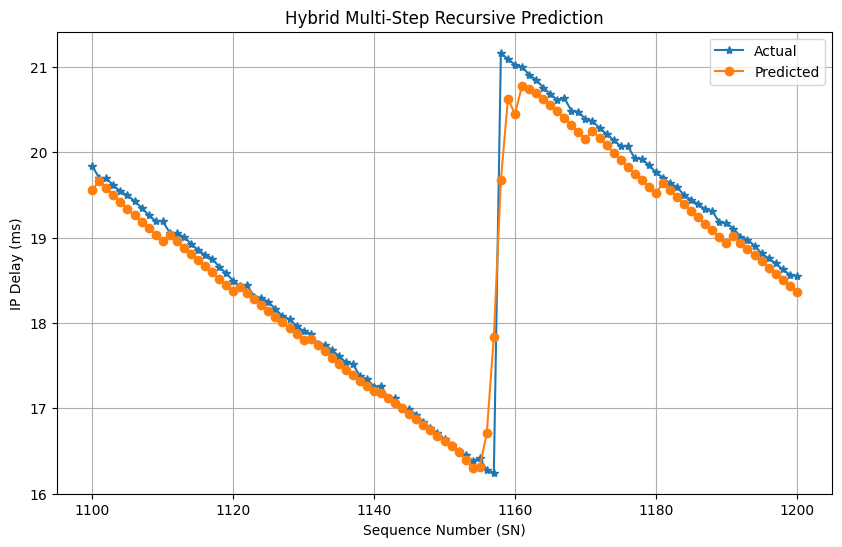

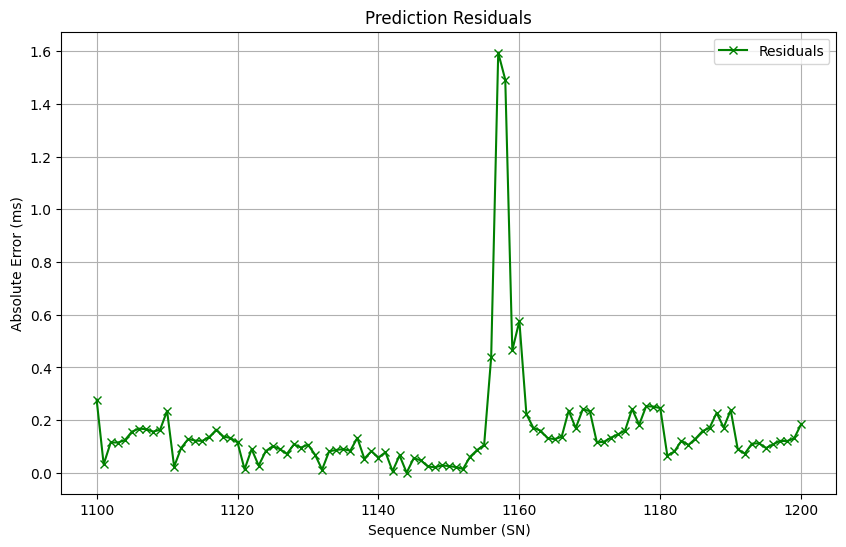

Residual Summary:
 count    3470.000000
mean        0.177898
std         0.315722
min         0.000183
25%         0.064419
50%         0.108479
75%         0.170793
max         3.296829
Name: Absolute Difference (ms), dtype: float64


In [11]:
filtered_df = result_df[(result_df['SN'] >= 1100) & (result_df['SN'] <= 1200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0345 - val_loss: 0.0045
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0026 - val_loss: 0.0034
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - val_loss: 0.0037
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/ste

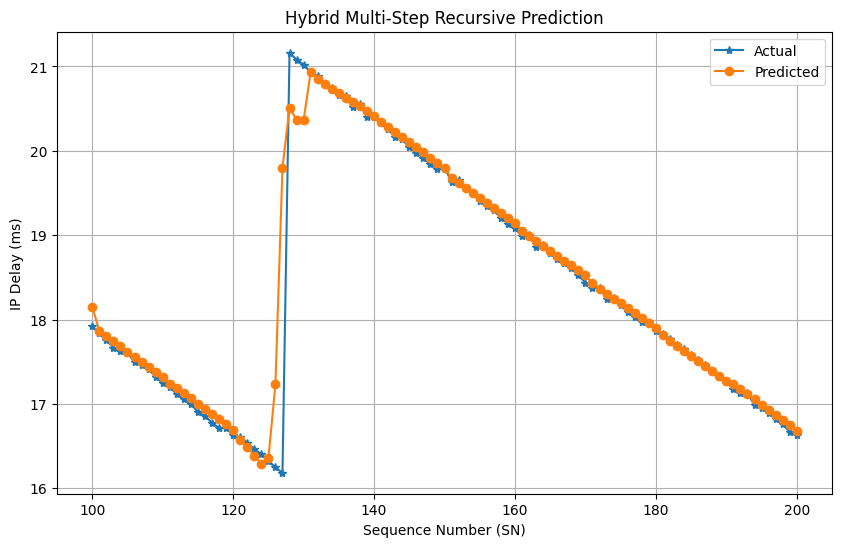

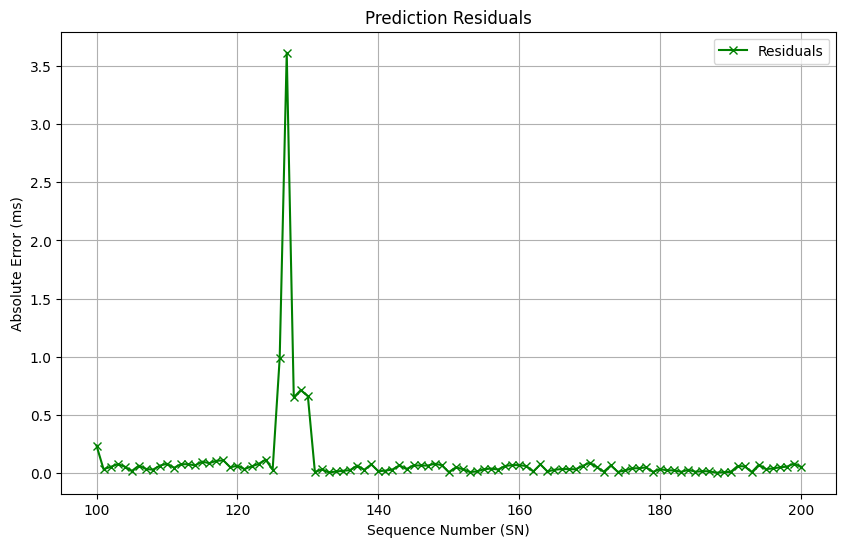

Residual Summary:
 count    3470.000000
mean        0.107955
std         0.295818
min         0.000014
25%         0.017421
50%         0.037018
75%         0.064071
max         3.894803
Name: Absolute Difference (ms), dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())



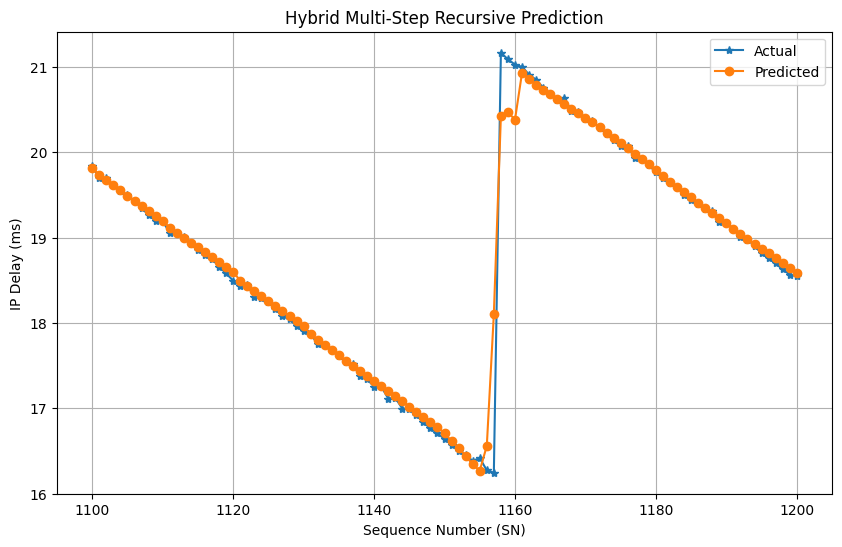

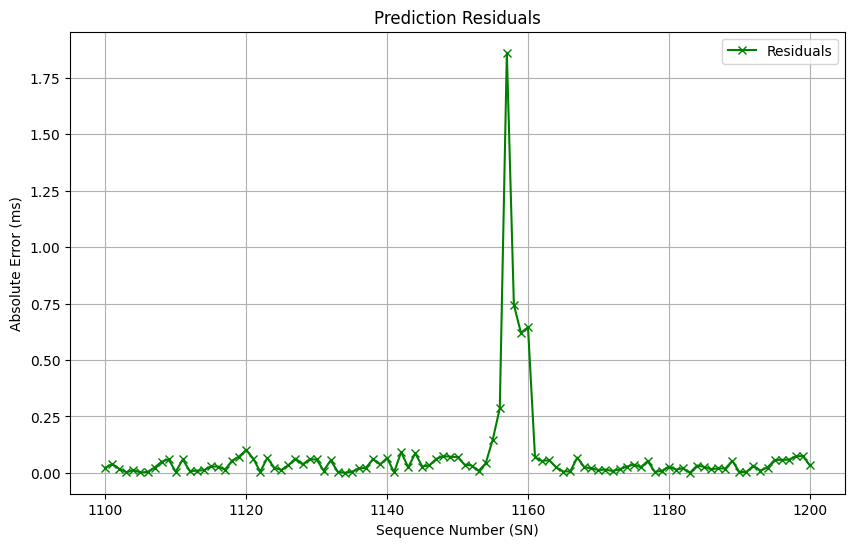

Residual Summary:
 count    3470.000000
mean        0.107955
std         0.295818
min         0.000014
25%         0.017421
50%         0.037018
75%         0.064071
max         3.894803
Name: Absolute Difference (ms), dtype: float64


In [13]:
filtered_df = result_df[(result_df['SN'] >= 1100) & (result_df['SN'] <= 1200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()


print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0925 - val_loss: 0.0149
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0138 - val_loss: 0.0101
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0092 - val_loss: 0.0080
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0079 - val_loss: 0.0070
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0094 - val_loss: 0.0079
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0065 - val_loss: 0.0056
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0059 - val_loss: 0.0050
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0048 - val_loss: 0.0095
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0087 - val_loss: 0.0042
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - l

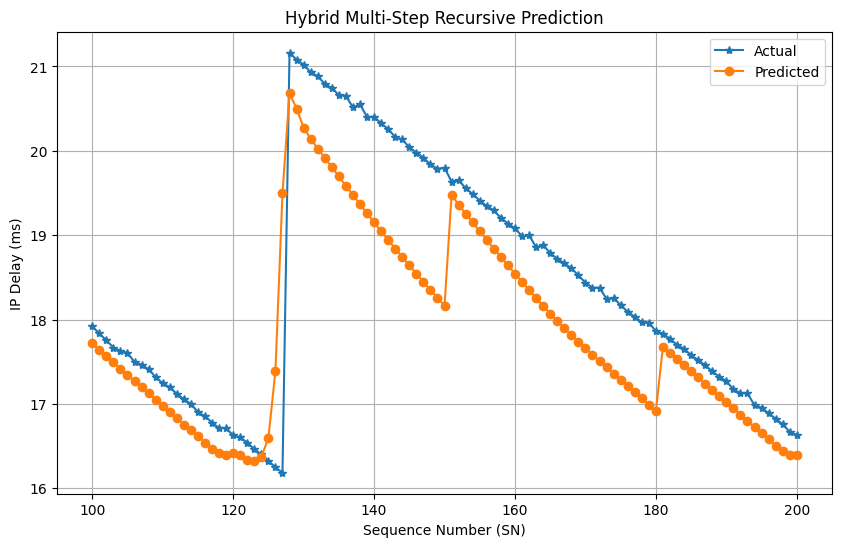

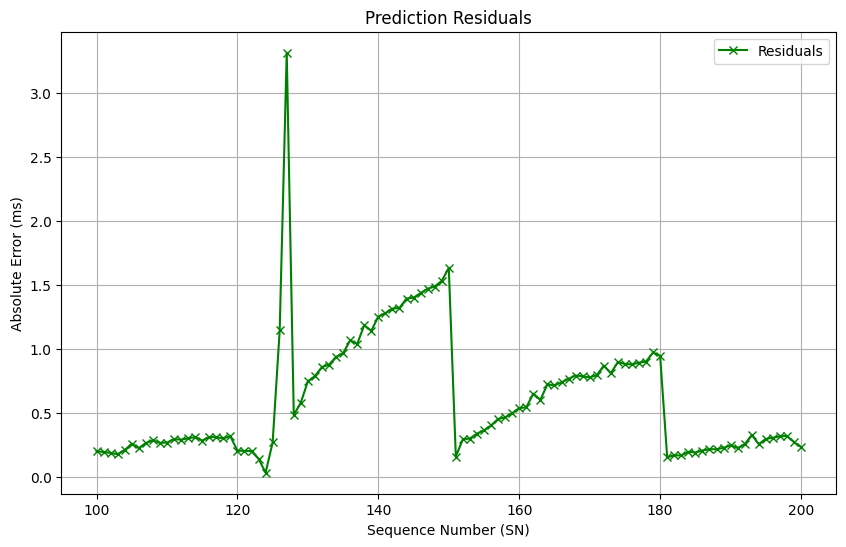

Residual Summary:
 count    3450.000000
mean        0.716019
std         0.534906
min         0.000197
25%         0.304698
50%         0.613799
75%         1.036719
max         4.136634
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 30
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0945 - val_loss: 0.0136
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0128 - val_loss: 0.0088
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0099 - val_loss: 0.0082
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0076 - val_loss: 0.0064
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0078 - val_loss: 0.0051
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0064 - val_loss: 0.0047
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0071 - val_loss: 0.0060
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0056 - val_loss: 0.0037
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0060 - val_loss: 0.0037
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0060 - val_loss: 0.0042
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0056 - val_loss: 0.0034
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/ste

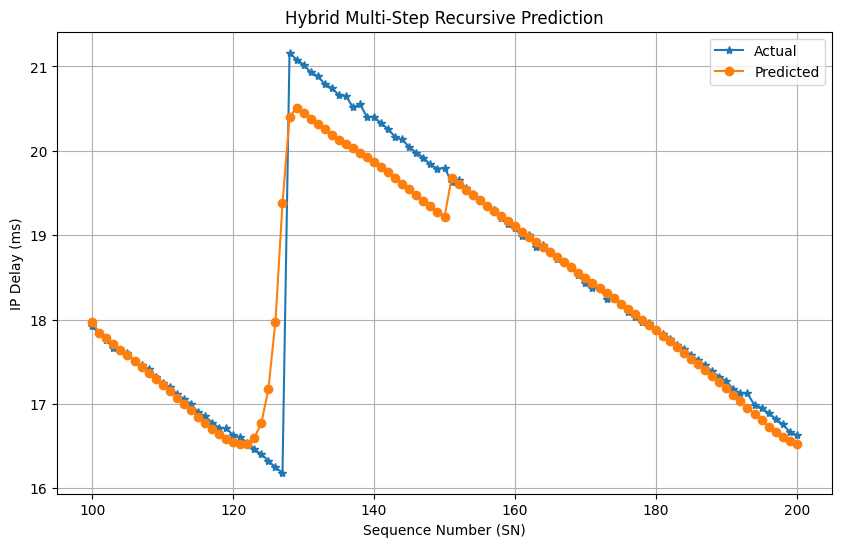

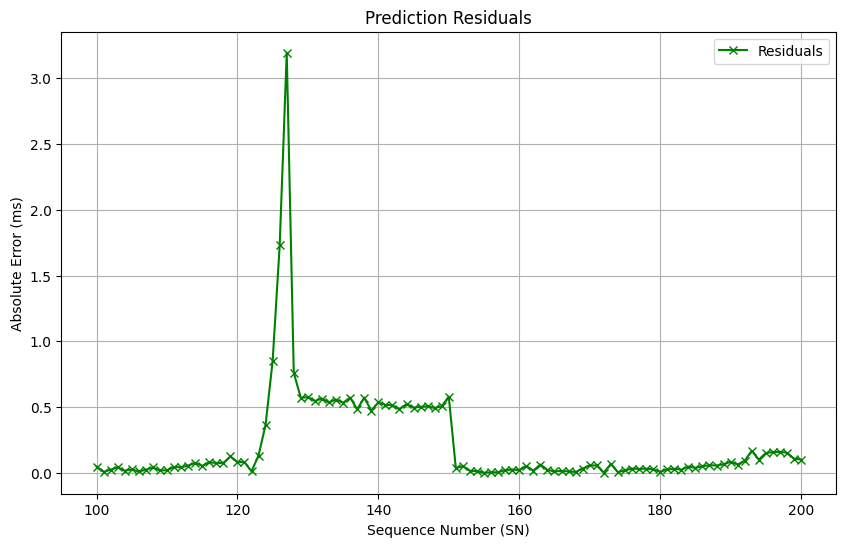

Residual Summary:
 count    3450.000000
mean        0.246503
std         0.394138
min         0.000041
25%         0.031775
50%         0.079850
75%         0.420832
max         4.041231
Name: Absolute Difference (ms), dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 50
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0724 - val_loss: 0.0119
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0111 - val_loss: 0.0084
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0089 - val_loss: 0.0061
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0072 - val_loss: 0.0069
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0089 - val_loss: 0.0066
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0071 - val_loss: 0.0076
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0066 - val_loss: 0.0054
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0058 - val_loss: 0.0045
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0060 - val_loss: 0.0043
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0053 - val_loss: 0.0040
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.

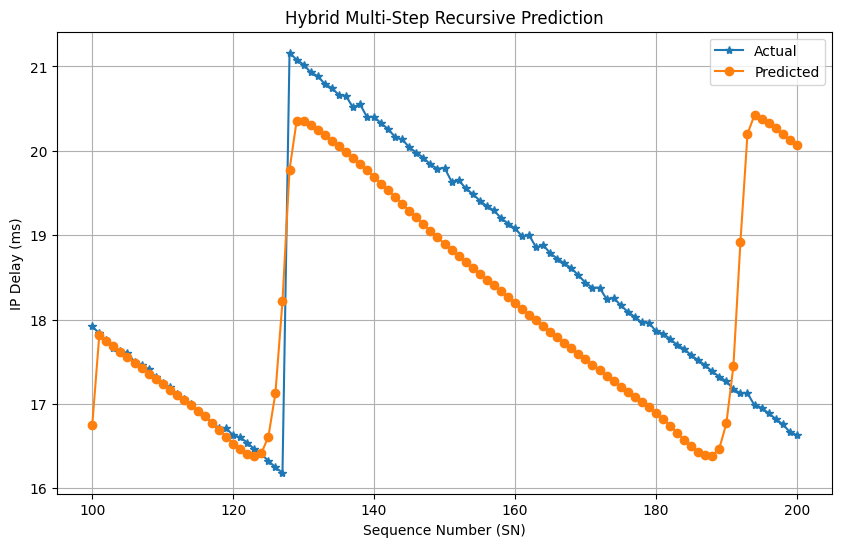

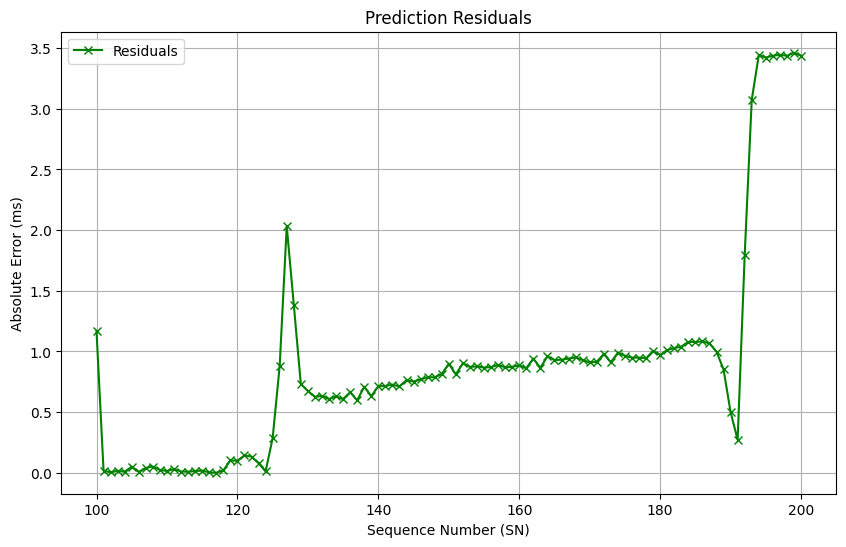

Residual Summary:
 count    3400.000000
mean        0.956202
std         0.875909
min         0.000533
25%         0.409850
50%         0.779053
75%         1.114736
max         4.194209
Name: Absolute Difference (ms), dtype: float64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 100
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())
